In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("electricity_consumption_and_production.csv")
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
df = df.reset_index(drop=False, allow_duplicates=True)

df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')

ts = df['Consumption'].sort_index()
ts.head()

DateTime
2019-01-01 00:00:00    6352
2019-01-01 01:00:00    6116
2019-01-01 02:00:00    5873
2019-01-01 03:00:00    5682
2019-01-01 04:00:00    5557
Name: Consumption, dtype: int64

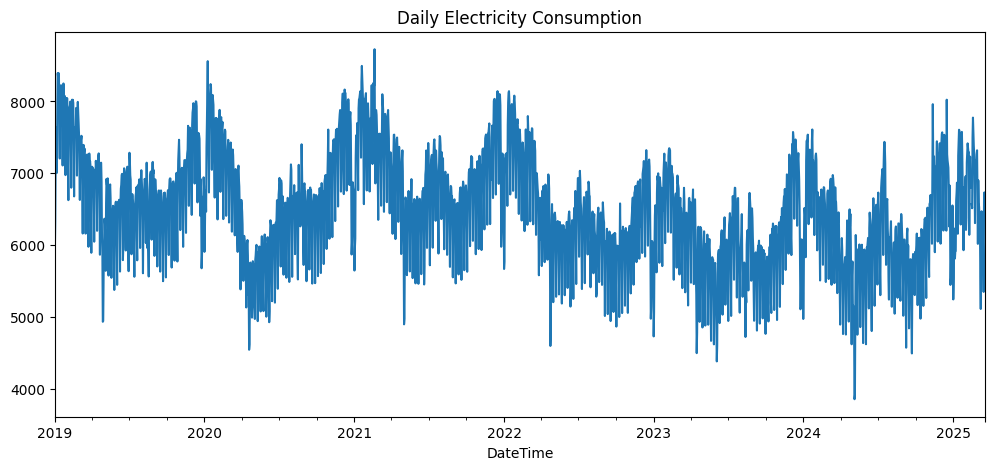

In [4]:
daily_ts = ts.resample('D').mean()

daily_ts.plot(figsize=(12,5))
plt.title("Daily Electricity Consumption")
plt.show()

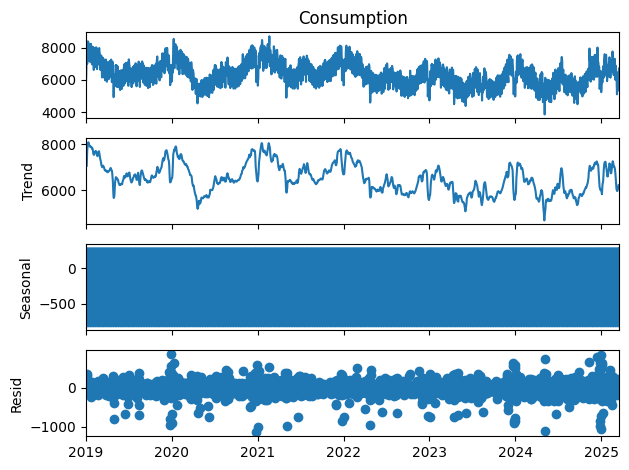

In [7]:
daily_ts = daily_ts.interpolate()

decomposition = seasonal_decompose(daily_ts, model='additive', period=7)
decomposition.plot()
plt.show()

<Figure size 1200x400 with 0 Axes>

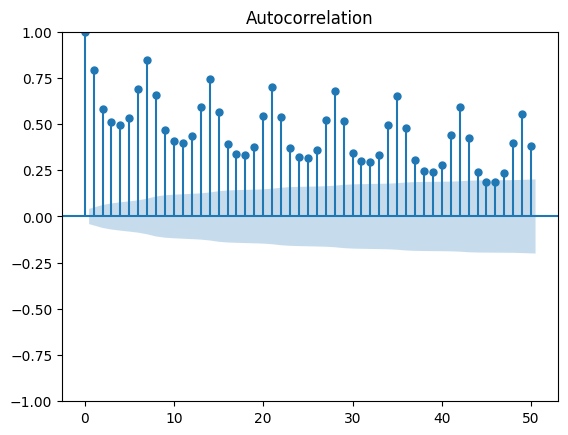

<Figure size 1200x400 with 0 Axes>

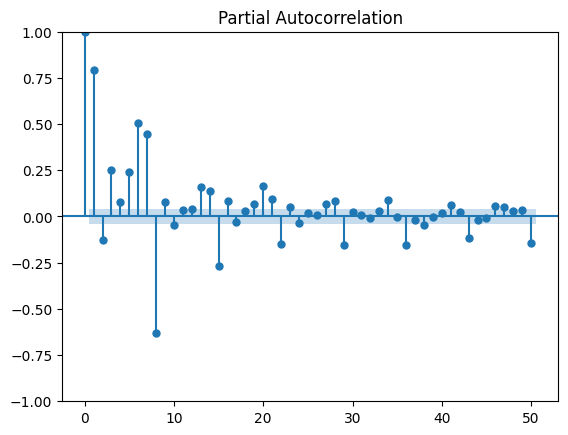

In [8]:
plt.figure(figsize=(12,4))
plot_acf(daily_ts, lags=50)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(daily_ts, lags=50)
plt.show()

In [9]:
result = adfuller(daily_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is NOT stationary")

ADF Statistic: -3.388397783787906
p-value: 0.011360806629429168
Series is stationary


In [11]:
train_size = int(len(daily_ts) * 0.8)
train = daily_ts[:train_size]
test = daily_ts[train_size:]

model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)
fit = model.fit()
forecast_test = fit.forecast(len(test))

mae = mean_absolute_error(test, forecast_test)
rmse = np.sqrt(mean_squared_error(test, forecast_test))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1304.750910733409
RMSE: 1443.991200732666


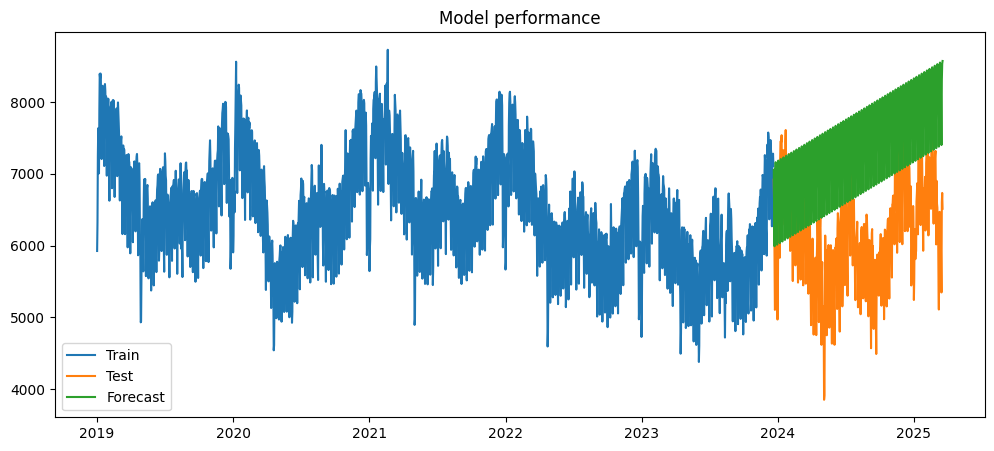

In [12]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_test, label="Forecast")

plt.legend()
plt.title("Model performance")
plt.show()

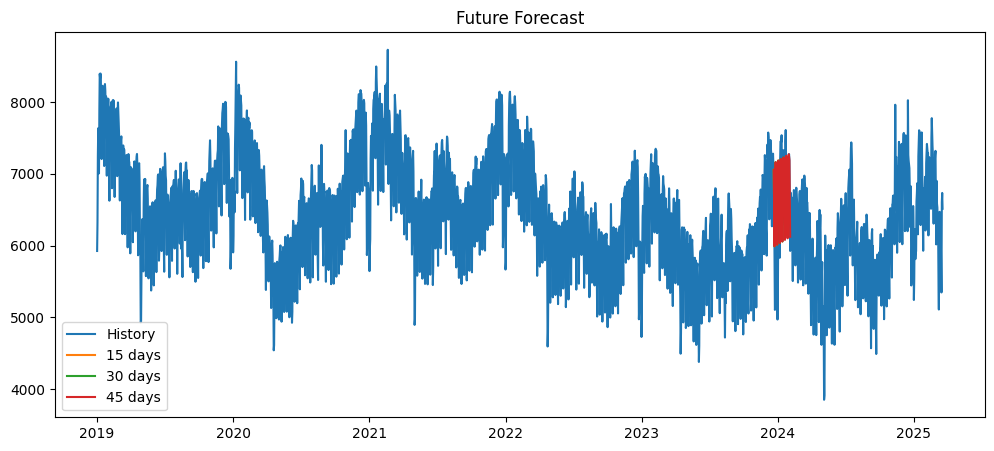

In [14]:
future_15 = fit.forecast(15)
future_30 = fit.forecast(30)
future_45 = fit.forecast(45)

plt.figure(figsize=(12,5))

plt.plot(daily_ts.index, daily_ts, label="History")

plt.plot(future_15.index, future_15, label="15 days")
plt.plot(future_30.index, future_30, label="30 days")
plt.plot(future_45.index, future_45, label="45 days")

plt.legend()
plt.title("Future Forecast")
plt.show()